In [2]:
import os
import zipfile
import pandas as pd
from pathlib import Path
try:
    from google.colab import drive
    COLAB = True
except Exception:
    drive = None
    COLAB = False

base_dir = Path.cwd()
project_root = base_dir if base_dir.name != 'models' else base_dir.parent
models_dir = project_root / 'models'
scalers_dir = project_root / 'scalers'
data_checkpoints_dir = project_root / 'data' / 'checkpoints'

models_dir.mkdir(parents=True, exist_ok=True)
scalers_dir.mkdir(parents=True, exist_ok=True)
data_checkpoints_dir.mkdir(parents=True, exist_ok=True)

local_archive_path = Path(r"C:/Users/Tero G/Desktop/Tero Final Year Project/archive.zip")

def process_cicids_dataset(zip_file_path):
    """
    Unzips the CICIDS2017 dataset, loads it, and performs initial EDA and
    feature engineering steps.

    Args:
        zip_file_path (str): The full path to the archive.zip file in Google Drive.

    Returns:
        pd.DataFrame: The processed DataFrame, or None if an error occurs.
    """
    if COLAB and drive is not None:
        print("Mounting Google Drive...")
        try:
            drive.mount('/content/drive')
            print("Google Drive mounted.")
        except Exception as e:
            print(f"Error mounting Google Drive: {e}")
            return None

        extract_dir = "/content/cicids2017"
    else:
        extract_dir = str(project_root / 'cicids2017')
    if not os.path.exists(extract_dir):
        os.makedirs(extract_dir)

    print(f"Unzipping {zip_file_path} to {extract_dir}...")
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Unzipping complete.")
    except FileNotFoundError:
        print(f"Error: The zip file '{zip_file_path}' was not found. Please check the path.")
        return None
    except Exception as e:
        print(f"An error occurred during unzipping: {e}")
        return None

    # Find and load Parquet files
    all_files = os.listdir(extract_dir)
    parquet_files = [os.path.join(extract_dir, f) for f in all_files if f.endswith('.parquet')]

    if not parquet_files:
        print(f"No Parquet files found in '{extract_dir}'. Please ensure the zip contains Parquets.")
        return None

    print(f"Found {len(parquet_files)} Parquet files. Loading and concatenating...")
    dfs = []
    for f in parquet_files:
        try:
            df = pd.read_parquet(f)
            dfs.append(df)
            print(f"Successfully loaded {os.path.basename(f)}")
        except Exception as e:
            print(f"Error loading {f}: {e}")
            continue

    if not dfs:
        print("No DataFrames could be loaded successfully.")
        return None

    df_combined = pd.concat(dfs, ignore_index=True)
    print("All Parquet files combined into a single DataFrame.")
    print(f"Initial DataFrame shape: {df_combined.shape}")

    # --- Initial EDA ---
    print("\n--- Initial Exploratory Data Analysis (EDA) ---")
    print("DataFrame Head:")
    print(df_combined.head())
    print("\nDataFrame Info (first 5 columns):")
    df_combined.iloc[:, :5].info() # Show info for a few columns for brevity
    print("\nDataFrame Description (numerical columns only, first 5 rows):")
    print(df_combined.describe().iloc[:, :5]) # Show describe for a few columns
    print("\nMissing Values (top 10 columns with most missing values):")
    missing_counts = df_combined.isnull().sum()
    print(missing_counts[missing_counts > 0].sort_values(ascending=False).head(10))

    # --- Feature Engineering (Common for CICIDS2017) ---
    print("\n--- Performing Feature Engineering ---")

    # Clean column names (remove leading/trailing spaces and special characters)
    df_combined.columns = df_combined.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.replace('.', '', regex=False)
    print("Cleaned column names.")

    # Process 'Label' column separately to ensure it's not coerced to numeric before mapping
    if 'Label' in df_combined.columns:
        # Preserve original string labels before binary conversion
        df_combined['Attack_Type_Original'] = df_combined['Label'].astype(str).str.strip()
        print("Original 'Attack_Type_Original' column created.")
        print("Unique values in 'Attack_Type_Original' column:")
        print(df_combined['Attack_Type_Original'].value_counts())

        # First, ensure 'Label' is string type for proper comparison
        df_combined['Label'] = df_combined['Label'].astype(str).str.strip().str.lower()
        print("Unique values in 'Label' column before conversion to binary:")
        print(df_combined['Label'].value_counts())
        # Convert labels to binary (Attack=1, Benign=0). Case-insensitive.
        df_combined['Label'] = df_combined['Label'].apply(lambda x: 0 if x == 'benign' else 1)
        print("Converted 'Label' column (Benign=0, Attack=1).")
        print("Unique values in 'Label' column after binary conversion:")
        print(df_combined['Label'].value_counts())
    else:
        print("Label column not found. Skipping label conversion.")

    # Convert all other columns to numeric where possible, coercing errors to NaN
    # This handles 'Infinity' strings, non-numeric values, etc.
    for col in df_combined.columns:
        if col not in ['Label', 'Attack_Type_Original'] and df_combined[col].dtype == 'object': # Exclude 'Attack_Type_Original' from numeric conversion
            df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce')
    print("Attempted to convert object columns (excluding 'Label' and 'Attack_Type_Original') to numeric.")

    # Replace infinite values with NaN
    df_combined.replace([float('inf'), -float('inf')], pd.NA, inplace=True)
    print("Replaced infinite values with NA.")

    # Handle missing values: Fill numerical with median, categorical with mode/unknown
    for col in df_combined.columns:
        if df_combined[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_combined[col]):
                median_val = df_combined[col].median()
                df_combined[col] = df_combined[col].fillna(median_val) # Removed inplace=True
                # print(f"Filled missing values in numerical column '{col}' with median: {median_val}")
            else: # Treat as categorical if not numeric (or still object after coercion)
                # Handle cases where mode might be empty (e.g., all NaNs in a column)
                mode_val = df_combined[col].mode()[0] if not df_combined[col].mode().empty else 'unknown'
                df_combined[col] = df_combined[col].fillna(mode_val) # Removed inplace=True
                # print(f"Filled missing values in categorical column '{col}' with mode/unknown: {mode_val}")
    print("Handled missing values (numerical with median, others with mode/unknown).")


    print("\n--- Feature Engineering Complete ---")
    print(f"Final DataFrame shape: {df_combined.shape}")
    print("DataFrame Info after processing (first 5 columns):")
    df_combined.iloc[:, :5].info()
    print("\nMissing Values after processing:")
    missing_counts_final = df_combined.isnull().sum()
    print(missing_counts_final[missing_counts_final > 0].sort_values(ascending=False).head(10))

    return df_combined

# --- Example Usage ---
# IMPORTANT: Replace this with the local path to your archive.zip file if needed.
# Example: `zip_file_path = base_dir / 'archive.zip'`.
zip_file_path = local_archive_path

cicids_df = process_cicids_dataset(zip_file_path)

if cicids_df is not None:
    print("\nProcessed CICIDS2017 DataFrame is ready!")
    print(cicids_df.head())

    # --- Checkpoint: Save processed DataFrame ---
    output_dir = str(data_checkpoints_dir)
    processed_df_path = os.path.join(output_dir, 'processed_cicids_data.parquet')
    cicids_df.to_parquet(processed_df_path, index=False)
    print(f"Processed DataFrame saved to: {processed_df_path}")
else:
    print("Failed to process the CICIDS2017 dataset.")

Unzipping C:\Users\Tero G\Desktop\Tero Final Year Project\archive.zip to c:\Users\Tero G\Desktop\Tero Final Year Project\ids-sytem\cicids2017...
Unzipping complete.
Found 8 Parquet files. Loading and concatenating...
Successfully loaded Benign-Monday-no-metadata.parquet
Successfully loaded Botnet-Friday-no-metadata.parquet
Successfully loaded Bruteforce-Tuesday-no-metadata.parquet
Successfully loaded DDoS-Friday-no-metadata.parquet
Successfully loaded DoS-Wednesday-no-metadata.parquet
Successfully loaded Infiltration-Thursday-no-metadata.parquet
Successfully loaded Portscan-Friday-no-metadata.parquet
Successfully loaded WebAttacks-Thursday-no-metadata.parquet
All Parquet files combined into a single DataFrame.
Initial DataFrame shape: (2313810, 78)

--- Initial Exploratory Data Analysis (EDA) ---
DataFrame Head:
   Protocol  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0         6              4                  2                       0   
1         6              1    

KeyboardInterrupt: 

## Binary Classification: Benign vs. Non-Benign Traffic

First, we'll train models to classify network traffic as either `Benign` (0) or `Non-Benign` (1). We'll use Random Forest and XGBoost for this task.

In [8]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Prepare features (X) and target (y)
# The cicids_df should already be clean from NaNs and Infs due to processing in G02TD5K6TsN-.
# Exclude 'Attack_Type_Original' as it's not a feature for binary classification
X = cicids_df.drop(['Label', 'Attack_Type_Original'], axis=1)
y = cicids_df['Label']

In [11]:
# Verify no NaNs or Infs remain
if X.isnull().sum().sum() > 0 or X.isin([np.inf, -np.inf]).sum().sum() > 0:
    print("Warning: NaNs or Infs still present in X after imputation. Review data cleaning.")

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Target distribution (0=Benign, 1=Attack):")
print(y.value_counts())

Features shape: (2313810, 77)
Target shape: (2313810,)
Target distribution (0=Benign, 1=Attack):
Label
0    1977318
1     336492
Name: count, dtype: int64


In [12]:
# Verify no NaNs or Infs remain
if X.isnull().sum().sum() > 0 or X.isin([np.inf, -np.inf]).sum().sum() > 0:
    print("Warning: NaNs or Infs still present in X after imputation. Review data cleaning.")

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print("Target distribution (0=Benign, 1=Attack):")
print(y.value_counts())

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Check target distribution in train and test sets
print("\nTarget distribution in Training Set:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in Test Set:")
print(y_test.value_counts(normalize=True))

Features shape: (2313810, 77)
Target shape: (2313810,)
Target distribution (0=Benign, 1=Attack):
Label
0    1977318
1     336492
Name: count, dtype: int64
X_train shape: (1619667, 77)
X_test shape: (694143, 77)
y_train shape: (1619667,)
y_test shape: (694143,)

Target distribution in Training Set:
Label
0    0.854573
1    0.145427
Name: proportion, dtype: float64

Target distribution in Test Set:
Label
0    0.854572
1    0.145428
Name: proportion, dtype: float64


### Random Forest Classifier for Binary Classification


--- Training Random Forest Classifier ---
Random Forest training complete. Evaluating...

--- Random Forest Classifier Performance ---
Accuracy: 0.9988
Precision: 0.9972
Recall: 0.9945
F1 Score: 0.9959
ROC AUC Score: 0.9998

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    593195
           1       1.00      0.99      1.00    100948

    accuracy                           1.00    694143
   macro avg       1.00      1.00      1.00    694143
weighted avg       1.00      1.00      1.00    694143


Confusion Matrix:


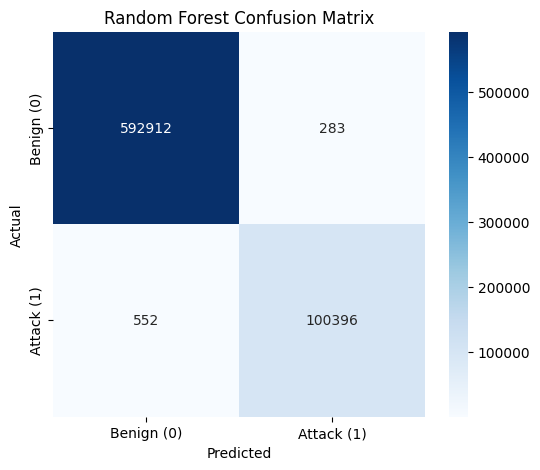

Random Forest model saved to: /content/drive/My Drive/IDS_Checkpoints/random_forest_binary_classifier.joblib


In [ ]:
import joblib # Import joblib for saving models
import os

print("\n--- Training Random Forest Classifier ---")
# Reduced n_estimators from 100 to 50 to speed up training
rf_classifier = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1) # n_jobs=-1 to use all available cores
rf_classifier.fit(X_train, y_train)

print("Random Forest training complete. Evaluating...")

y_pred_rf = rf_classifier.predict(X_test)
y_proba_rf = rf_classifier.predict_proba(X_test)[:, 1]

print("\n--- Random Forest Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Attack (1)'], yticklabels=['Benign (0)', 'Attack (1)'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Checkpoint: Save Random Forest Model ---
output_dir = str(data_checkpoints_dir)
rf_model_path = os.path.join(output_dir, 'random_forest_binary_classifier.joblib')
joblib.dump(rf_classifier, rf_model_path)
print(f"Random Forest model saved to: {rf_model_path}")

### XGBoost Classifier for Binary Classification


--- Training XGBoost Classifier ---
XGBoost training complete. Evaluating...

--- XGBoost Classifier Performance ---
Accuracy: 0.9988
Precision: 0.9979
Recall: 0.9936
F1 Score: 0.9957
ROC AUC Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    593195
           1       1.00      0.99      1.00    100948

    accuracy                           1.00    694143
   macro avg       1.00      1.00      1.00    694143
weighted avg       1.00      1.00      1.00    694143


Confusion Matrix:


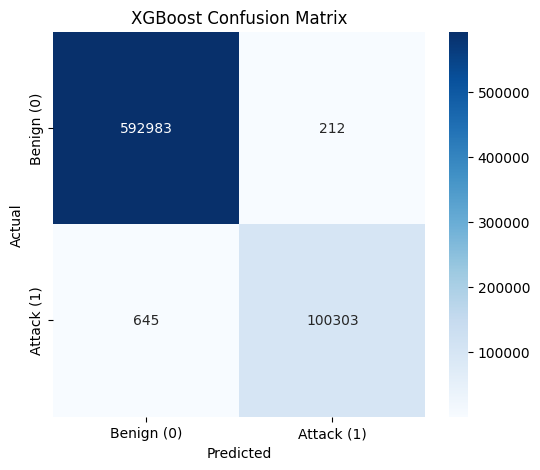

XGBoost model saved to: /content/drive/My Drive/IDS_Checkpoints/xgboost_binary_classifier.joblib


In [ ]:
import joblib # Import joblib for saving models
import os
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Training XGBoost Classifier ---")
# XGBoost is highly optimized; using `tree_method='hist'` and `enable_categorical=True` can speed it up
# if categorical features are identified, otherwise `objective='binary:logistic'` is for binary classification.
xgb_classifier = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=100,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1 # Use all available cores
)
xgb_classifier.fit(X_train, y_train)

print("XGBoost training complete. Evaluating...")

y_pred_xgb = xgb_classifier.predict(X_test)
y_proba_xgb = xgb_classifier.predict_proba(X_test)[:, 1]

print("\n--- XGBoost Classifier Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign (0)', 'Attack (1)'], yticklabels=['Benign (0)', 'Attack (1)'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Checkpoint: Save XGBoost Model ---
output_dir = str(data_checkpoints_dir)
xgb_model_path = os.path.join(output_dir, 'xgboost_binary_classifier.joblib')
joblib.dump(xgb_classifier, xgb_model_path)
print(f"XGBoost model saved to: {xgb_model_path}")

## Multi-class Classification: Attack Type Identification with LSTM

Now, we'll focus on classifying the specific types of attacks using an LSTM neural network. For this, we'll filter our dataset to include only the non-benign traffic and use the `Attack_Type_Original` column as our target.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Filter for non-benign traffic for multi-class classification
attack_df = cicids_df[cicids_df['Label'] == 1].copy()

# Drop the binary 'Label' column as we now care about 'Attack_Type_Original'
attack_df = attack_df.drop('Label', axis=1)

# NOTE: Removing this line as it was unexpectedly dropping 'Attack_Type_Original'
# attack_df = attack_df.dropna(axis=1, how='all')

# Prepare features (X_attack) and multi-class target (y_attack_original)
X_attack = attack_df.drop('Attack_Type_Original', axis=1)
y_attack_original = attack_df['Attack_Type_Original']

# Handle any potential remaining NaNs in features by filling with the mean of the column
X_attack = X_attack.fillna(X_attack.mean())

# Verify no NaNs or Infs remain
if X_attack.isnull().sum().sum() > 0 or X_attack.isin([np.inf, -np.inf]).sum().sum() > 0:
    print("Warning: NaNs or Infs still present in X_attack after imputation. Review data cleaning.")

print(f"Attack Features shape: {X_attack.shape}")
print(f"Attack Target shape: {y_attack_original.shape}")
print("Attack Type Distribution:")
print(y_attack_original.value_counts())

# 1. Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_attack_original)

# Save the label encoder for future use
output_dir = str(data_checkpoints_dir)
label_encoder_path = os.path.join(output_dir, 'attack_type_label_encoder.joblib')
joblib.dump(label_encoder, label_encoder_path)
print(f"LabelEncoder saved to: {label_encoder_path}")

# 2. One-hot encode the integer labels
y_one_hot = to_categorical(y_encoded)
num_classes = y_one_hot.shape[1]
print(f"Number of attack classes: {num_classes}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_attack)

# Save the scaler for future use
scaler_path = os.path.join(output_dir, 'attack_type_scaler.joblib')
joblib.dump(scaler, scaler_path)
print(f"Scaler saved to: {scaler_path}")

# Reshape data for LSTM: (samples, timesteps, features)
# For tabular data, we often use 1 timestep if not dealing with sequences of events.
# Each row is treated as a single time step in a sequence.
num_features = X_scaled.shape[1]
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, num_features)
print(f"Reshaped X for LSTM: {X_reshaped.shape}")

# Split the dataset into training and testing sets
X_train_attack, X_test_attack, y_train_attack, y_test_attack = train_test_split(
    X_reshaped, y_one_hot, test_size=0.3, random_state=42, stratify=y_encoded # stratify by original encoded labels
)

print(f"X_train_attack shape: {X_train_attack.shape}")
print(f"X_test_attack shape: {X_test_attack.shape}")
print(f"y_train_attack shape: {y_train_attack.shape}")
print(f"y_test_attack shape: {y_test_attack.shape}")

Attack Features shape: (336492, 77)
Attack Target shape: (336492,)
Attack Type Distribution:
Attack_Type_Original
DoS Hulk                      172846
DDoS                          128014
DoS GoldenEye                  10286
FTP-Patator                     5931
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3219
PortScan                        1956
Web Attack � Brute Force        1470
Bot                             1437
Web Attack � XSS                 652
Infiltration                      36
Web Attack � Sql Injection        21
Heartbleed                        11
Name: count, dtype: int64
LabelEncoder saved to: /content/drive/My Drive/IDS_Checkpoints/attack_type_label_encoder.joblib
Number of attack classes: 14
Scaler saved to: /content/drive/My Drive/IDS_Checkpoints/attack_type_scaler.joblib
Reshaped X for LSTM: (336492, 1, 77)
X_train_attack shape: (235544, 1, 77)
X_test_attack shape: (100948, 1, 77)
y_train_attack shape: 

### Build and Train LSTM Model


--- Building LSTM Model ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        71,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │           714 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,964 (300.64 KB)

 Trainable params: 76,964 (300.64 KB)

 Non-trainable params: 0 (0.00 B)


--- Training LSTM Model ---
Epoch 1/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 18s 5ms/step - accuracy: 0.9775 - loss: 0.1072 - val_accuracy: 0.9938 - val_loss: 0.0227
Epoch 2/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9931 - loss: 0.0320 - val_accuracy: 0.9961 - val_loss: 0.0147
Epoch 3/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9945 - loss: 0.0201 - val_accuracy: 0.9959 - val_loss: 0.0140
Epoch 4/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9950 - loss: 0.0183 - val_accuracy: 0.9961 - val_loss: 0.0157
Epoch 5/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9954 - loss: 0.0170 - val_accuracy: 0.9962 - val_loss: 0.0120
Epoch 6/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9956 - loss: 0.0153 - val_accuracy: 0.9963 - val_loss: 0.0119
Epoch 7/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9956 - loss: 0.0172 - val_accuracy: 0.9965 - val_loss: 0.0111
Epoch 8/20
2945/2945 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step -

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


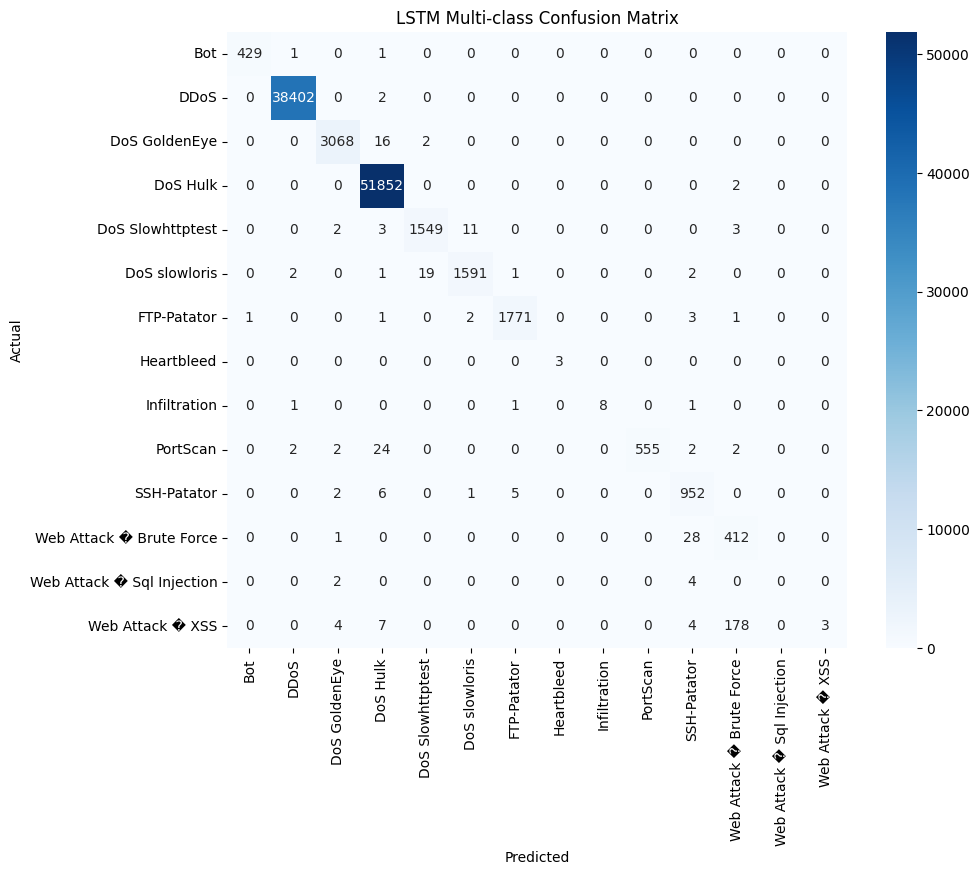

LSTM model saved to: /content/drive/My Drive/IDS_Checkpoints/lstm_multi_class_classifier.h5


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

print("\n--- Building LSTM Model ---")

model = Sequential([
    LSTM(100, activation='relu', input_shape=(X_train_attack.shape[1], X_train_attack.shape[2])),
    Dropout(0.2),
    Dense(50, activation='relu'),
    Dropout(0.2),
    Dense(num_classes, activation='softmax') # Output layer with softmax for multi-class
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\n--- Training LSTM Model ---")
history = model.fit(
    X_train_attack, y_train_attack,
    epochs=20, # You can adjust the number of epochs
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

print("LSTM training complete. Evaluating...")

# Evaluate the model
loss, accuracy = model.evaluate(X_test_attack, y_test_attack, verbose=0)
print(f"\n--- LSTM Model Performance ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

y_pred_proba_lstm = model.predict(X_test_attack)
y_pred_lstm = np.argmax(y_pred_proba_lstm, axis=1)
y_true_lstm = np.argmax(y_test_attack, axis=1)

print("\nClassification Report:")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=label_encoder.classes_))

print("\nConfusion Matrix:")
cm_lstm = confusion_matrix(y_true_lstm, y_pred_lstm)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('LSTM Multi-class Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# --- Checkpoint: Save LSTM Model ---
output_dir = str(data_checkpoints_dir)
lstm_model_path = os.path.join(output_dir, 'lstm_multi_class_classifier.h5')
model.save(lstm_model_path)
print(f"LSTM model saved to: {lstm_model_path}")

In [1]:
%%capture
!pip install streamlit
print("Streamlit installed successfully!")

## Streamlit UI for IDS System

This Streamlit application will allow you to:

1.  **Upload a CSV file** containing raw network traffic features.
2.  **Preprocess** the uploaded data using the `StandardScaler` and `LabelEncoder` saved during training.
3.  Get **binary classification predictions** (Benign/Attack) from the trained **Random Forest** and **XGBoost** models.
4.  Get **multi-class classification predictions** (specific attack types) from the trained **LSTM** model.
5.  **Visualize** the results.

To run the app, execute the next cell. It will provide a public URL to access the UI.

In [7]:
# This cell previously contained the Streamlit app code.
# The app code is now embedded as a string in the next cell (469acf78)
# for correct execution via `streamlit run`.
# Executing this cell now does nothing.

In [ ]:
import subprocess
import sys
import os

# Path to the streamlit app (already exists in models/ directory)
streamlit_app_path = str(project_root / 'models' / 'streamlit_app.py')

print(f'Launching Streamlit app from: {streamlit_app_path}')

cmd = [
    sys.executable, '-m', 'streamlit', 'run', streamlit_app_path,
    '--browser.gatherUsageStats', 'false',
    '--server.port', '8501',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false'
]

# On Windows: open Streamlit in its own console so it does not block or crash the notebook
if os.name == 'nt':
    process = subprocess.Popen(cmd, creationflags=subprocess.CREATE_NEW_CONSOLE)
else:
    process = subprocess.Popen(cmd)

print(f'Streamlit app started (PID: {process.pid})')
print('Open http://localhost:8501 in your browser.')
print('To stop: process.terminate()')


In [ ]:
# 1. Initialize git repo
!git init

# 2. Add all files
!git add .

# 3. Commit
!git commit -m "Initial commit: Streamlit app"

# 4. Create repo on GitHub, then connect (replace with your actual repo URL)
!git remote add origin https://github.com/YOUR_USERNAME/your-repo.git

# 5. Push
!git push origin main

# 6. Deploy on Streamlit Cloud (share.streamlit.io)
